---
## Section 0 — Setup & Load

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# ── Load dataset ─────────────────────────────────────────────────
df = pd.read_csv('cmi_module1_clean-1.csv')
print(f"Dataset shape: {df.shape}")

# ── Class distribution ───────────────────────────────────────────
print("\nsii class distribution:")
dist = df['sii'].value_counts().sort_index()
for cls, cnt in dist.items():
    print(f"  sii={cls}: {cnt} ({cnt/len(df)*100:.1f}%)")

Dataset shape: (8417, 32)

sii class distribution:
  sii=0.0: 5806 (69.0%)
  sii=1.0: 1578 (18.7%)
  sii=2.0: 947 (11.3%)
  sii=3.0: 86 (1.0%)


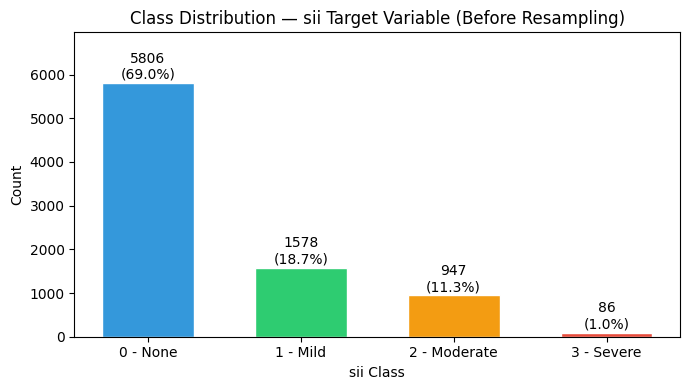


Imbalance ratio (majority/minority): 67.5x


In [ ]:
# ── Visualise class imbalance ────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#3498DB','#2ECC71','#F39C12','#E74C3C']
bars = ax.bar(
    ['0 - None','1 - Mild','2 - Moderate','3 - Severe'],
    dist.values, color=colors, edgecolor='white', width=0.6
)
for bar, cnt in zip(bars, dist.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{cnt}\n({cnt/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10)
ax.set_xlabel('sii Class')
ax.set_ylabel('Count')
ax.set_title('Class Distribution — sii Target Variable (Before Resampling)')
ax.set_ylim(0, dist.max() * 1.2)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print(f"\nImbalance ratio (majority/minority): {dist.max()/dist.min():.1f}x")

---
## Section 1 — Train/Test Split & Scaling

In [ ]:
# ── Feature / target split ───────────────────────────────────────
feature_cols = [c for c in df.columns if c != 'sii']
X = df[feature_cols]
y = df['sii']

print(f"Features: {X.shape[1]}")
print(f"Target classes: {sorted(y.unique())}")

# ── 80/20 stratified split ───────────────────────────────────────
# Stratified: proportional class representation in both sets
# random_state=42: consistent with all teammates
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print("\nTrain class distribution:")
print(y_train.value_counts().sort_index())
print("\nTest class distribution:")
print(y_test.value_counts().sort_index())

Features: 31
Target classes: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0)]

Train: 6733 rows | Test: 1684 rows

Train class distribution:
sii
0.0    4644
1.0    1262
2.0     758
3.0      69
Name: count, dtype: int64

Test class distribution:
sii
0.0    1162
1.0     316
2.0     189
3.0      17
Name: count, dtype: int64


In [ ]:
# ── Scale ────────────────────────────────────────────────────────
# Fit on training set ONLY — prevents data leakage into test set
# KNN is distance-based so scaling is mandatory
# Decision Tree is scale-invariant but scaled uniformly for consistency
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("StandardScaler applied — fit on training set only")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")

StandardScaler applied — fit on training set only
X_train_scaled: (6733, 31)
X_test_scaled:  (1684, 31)


---
## Section 2 — Helper Functions & Shared Config

In [ ]:
CLASSES = [0, 1, 2, 3]
CLASS_NAMES = ['None', 'Mild', 'Moderate', 'Severe']

# ── Shared hyperparameter grids ──────────────────────────────────
# Same grid tested for every technique — only the training data changes
DT_GRID = {
    'max_depth':         [3, 4, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion':         ['gini', 'entropy']
}
KNN_GRID = {
    'n_neighbors': [3, 5, 10, 15, 20],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan']
}
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def tune_and_evaluate(X_tr, y_tr, X_te, y_te, label):
    """
    1. GridSearchCV Decision Tree on (X_tr, y_tr)
    2. GridSearchCV KNN on (X_tr, y_tr)
    3. Evaluate both on (X_te, y_te)
    Returns: (dt_metrics, knn_metrics, dt_preds, knn_preds, dt_best_params, knn_best_params)
    """
    print(f"\nTuning Decision Tree on {label} data...")
    dt_gs = GridSearchCV(DecisionTreeClassifier(random_state=42), DT_GRID,
                         cv=CV, scoring='f1_weighted', n_jobs=-1)
    dt_gs.fit(X_tr, y_tr)
    best_dt = dt_gs.best_estimator_
    print(f"  Best params: {dt_gs.best_params_}")
    print(f"  Best CV F1:  {dt_gs.best_score_:.4f}")

    print(f"\nTuning KNN on {label} data...")
    knn_gs = GridSearchCV(KNeighborsClassifier(), KNN_GRID,
                          cv=CV, scoring='f1_weighted', n_jobs=-1)
    knn_gs.fit(X_tr, y_tr)
    best_knn = knn_gs.best_estimator_
    print(f"  Best params: {knn_gs.best_params_}")
    print(f"  Best CV F1:  {knn_gs.best_score_:.4f}")

    # Evaluate DT
    y_pred_dt   = best_dt.predict(X_te)
    y_prob_dt   = best_dt.predict_proba(X_te)
    y_bin       = label_binarize(y_te, classes=CLASSES)
    roc_dt      = roc_auc_score(y_bin, y_prob_dt, multi_class='ovr', average='weighted')
    dt_metrics  = {
        'Accuracy':  round(accuracy_score(y_te, y_pred_dt), 4),
        'Precision': round(precision_score(y_te, y_pred_dt, average='weighted', zero_division=0), 4),
        'Recall':    round(recall_score(y_te, y_pred_dt, average='weighted', zero_division=0), 4),
        'F1-score':  round(f1_score(y_te, y_pred_dt, average='weighted', zero_division=0), 4),
        'ROC-AUC':   round(roc_dt, 4),
    }

    # Evaluate KNN
    y_pred_knn  = best_knn.predict(X_te)
    y_prob_knn  = best_knn.predict_proba(X_te)
    roc_knn     = roc_auc_score(y_bin, y_prob_knn, multi_class='ovr', average='weighted')
    knn_metrics = {
        'Accuracy':  round(accuracy_score(y_te, y_pred_knn), 4),
        'Precision': round(precision_score(y_te, y_pred_knn, average='weighted', zero_division=0), 4),
        'Recall':    round(recall_score(y_te, y_pred_knn, average='weighted', zero_division=0), 4),
        'F1-score':  round(f1_score(y_te, y_pred_knn, average='weighted', zero_division=0), 4),
        'ROC-AUC':   round(roc_knn, 4),
    }

    return (dt_metrics, knn_metrics, y_pred_dt, y_pred_knn,
            dt_gs.best_params_, knn_gs.best_params_,
            y_prob_dt, y_prob_knn)


def print_metrics(metrics, model_name):
    print(f"  {model_name}")
    for k, v in metrics.items():
        print(f"    {k}: {v}")


def plot_confusion_pair(y_te, pred_dt, pred_knn, title, cmap):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, y_pred, name in zip(axes, [pred_dt, pred_knn], ['Decision Tree', 'KNN']):
        cm = confusion_matrix(y_te, y_pred, labels=CLASSES)
        ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
            ax=ax, colorbar=False, cmap=cmap
        )
        ax.set_title(f'{title} — {name}')
    plt.tight_layout()
    plt.savefig(f'confusion_{title.lower().replace(" ","_")}.png', dpi=150)
    plt.show()


# Accumulate results for final comparison table
all_results  = []   # (method, model, metrics_dict)
all_preds    = {}   # label -> y_pred
print("Helper functions ready.")

Helper functions ready.


---
## Section 3 — Baseline (No Resampling)
Both classifiers tuned and evaluated on the **original imbalanced** training data.  
Serves as the reference point for all subsequent techniques.

In [ ]:
print("=" * 55)
print("BASELINE — No Resampling")
print(f"Training set size: {len(y_train)} rows")
print("=" * 55)

(m_dt_base, m_knn_base,
 pred_dt_base, pred_knn_base,
 params_dt_base, params_knn_base,
 prob_dt_base, prob_knn_base) = tune_and_evaluate(
    X_train_scaled, y_train,
    X_test_scaled,  y_test,
    label='Baseline'
)

print("\n--- TEST SET RESULTS ---")
print_metrics(m_dt_base,  'Decision Tree')
print_metrics(m_knn_base, 'KNN')

all_results.append(('Baseline', 'Decision Tree', m_dt_base))
all_results.append(('Baseline', 'KNN',           m_knn_base))
all_preds['Baseline DT']  = pred_dt_base
all_preds['Baseline KNN'] = pred_knn_base

BASELINE — No Resampling
Training set size: 6733 rows

Tuning Decision Tree on Baseline data...
  Best params: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2}
  Best CV F1:  0.6078

Tuning KNN on Baseline data...
  Best params: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
  Best CV F1:  0.6114

--- TEST SET RESULTS ---
  Decision Tree
    Accuracy: 0.6811
    Precision: 0.5763
    Recall: 0.6811
    F1-score: 0.5987
    ROC-AUC: 0.668
  KNN
    Accuracy: 0.6568
    Precision: 0.5774
    Recall: 0.6568
    F1-score: 0.5986
    ROC-AUC: 0.6167


In [ ]:
# ── Baseline classification reports ──────────────────────────────
print("Decision Tree — Classification Report:")
print(classification_report(y_test, pred_dt_base, target_names=CLASS_NAMES, zero_division=0))
print("KNN — Classification Report:")
print(classification_report(y_test, pred_knn_base, target_names=CLASS_NAMES, zero_division=0))

Decision Tree — Classification Report:
              precision    recall  f1-score   support

        None       0.72      0.95      0.82      1162
        Mild       0.27      0.04      0.07       316
    Moderate       0.28      0.13      0.18       189
      Severe       0.00      0.00      0.00        17

    accuracy                           0.68      1684
   macro avg       0.32      0.28      0.27      1684
weighted avg       0.58      0.68      0.60      1684

KNN — Classification Report:
              precision    recall  f1-score   support

        None       0.71      0.90      0.80      1162
        Mild       0.26      0.13      0.17       316
    Moderate       0.26      0.09      0.13       189
      Severe       0.50      0.06      0.11        17

    accuracy                           0.66      1684
   macro avg       0.44      0.29      0.30      1684
weighted avg       0.58      0.66      0.60      1684



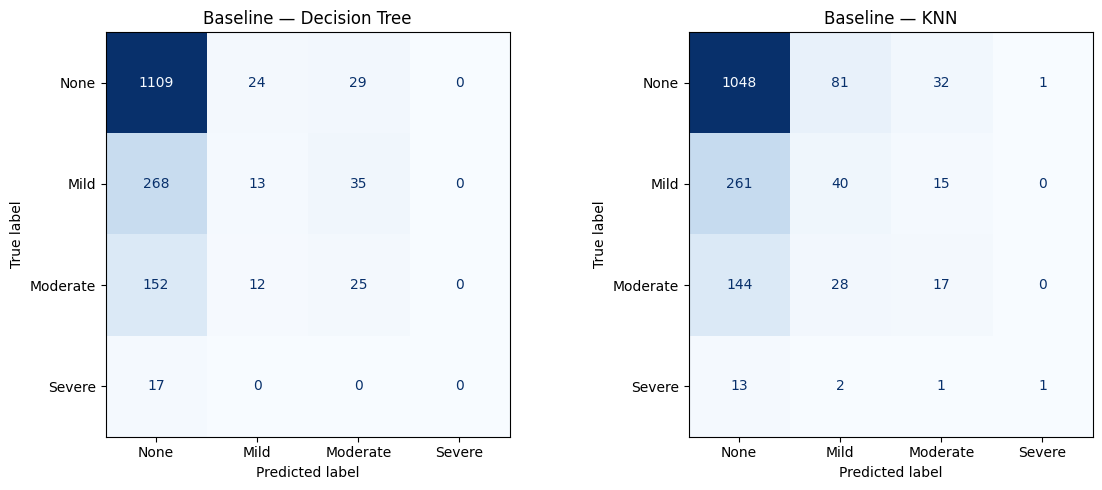

In [ ]:
plot_confusion_pair(y_test, pred_dt_base, pred_knn_base, 'Baseline', 'Blues')

---
## Section 4 — Random Oversampling
Randomly duplicates minority class samples in the **training set only** until all classes are balanced.  
No synthetic samples — existing minority samples are replicated.  
GridSearchCV is re-run on the oversampled training data to find the best hyperparameters for this distribution.

In [ ]:
# ── Apply Random Oversampling ────────────────────────────────────
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train_scaled, y_train)

print("Random Oversampling — Training Set")
print(f"Before: {len(y_train)} rows")
print(f"After:  {len(y_train_ros)} rows")
print("\nClass distribution after oversampling:")
unique, counts = np.unique(y_train_ros, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  sii={int(cls)}: {cnt}")

Random Oversampling — Training Set
Before: 6733 rows
After:  18576 rows

Class distribution after oversampling:
  sii=0: 4644
  sii=1: 4644
  sii=2: 4644
  sii=3: 4644


In [ ]:
print("=" * 55)
print("RANDOM OVERSAMPLING")
print(f"Training set size: {len(y_train_ros)} rows (balanced)")
print("=" * 55)

(m_dt_ros, m_knn_ros,
 pred_dt_ros, pred_knn_ros,
 params_dt_ros, params_knn_ros,
 prob_dt_ros, prob_knn_ros) = tune_and_evaluate(
    X_train_ros, y_train_ros,
    X_test_scaled, y_test,
    label='Random Oversampling'
)

print("\n--- TEST SET RESULTS ---")
print_metrics(m_dt_ros,  'Decision Tree')
print_metrics(m_knn_ros, 'KNN')

all_results.append(('Random Oversampling', 'Decision Tree', m_dt_ros))
all_results.append(('Random Oversampling', 'KNN',           m_knn_ros))
all_preds['ROS DT']  = pred_dt_ros
all_preds['ROS KNN'] = pred_knn_ros

RANDOM OVERSAMPLING
Training set size: 18576 rows (balanced)

Tuning Decision Tree on Random Oversampling data...
  Best params: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2}
  Best CV F1:  0.9062

Tuning KNN on Random Oversampling data...
  Best params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
  Best CV F1:  0.8800

--- TEST SET RESULTS ---
  Decision Tree
    Accuracy: 0.576
    Precision: 0.5698
    Recall: 0.576
    F1-score: 0.5728
    ROC-AUC: 0.5597
  KNN
    Accuracy: 0.5321
    Precision: 0.5962
    Recall: 0.5321
    F1-score: 0.5578
    ROC-AUC: 0.5941


In [ ]:
print("Decision Tree — Classification Report:")
print(classification_report(y_test, pred_dt_ros, target_names=CLASS_NAMES, zero_division=0))
print("KNN — Classification Report:")
print(classification_report(y_test, pred_knn_ros, target_names=CLASS_NAMES, zero_division=0))

Decision Tree — Classification Report:
              precision    recall  f1-score   support

        None       0.74      0.75      0.74      1162
        Mild       0.24      0.22      0.23       316
    Moderate       0.16      0.15      0.15       189
      Severe       0.05      0.06      0.05        17

    accuracy                           0.58      1684
   macro avg       0.29      0.30      0.29      1684
weighted avg       0.57      0.58      0.57      1684

KNN — Classification Report:
              precision    recall  f1-score   support

        None       0.77      0.64      0.69      1162
        Mild       0.25      0.36      0.30       316
    Moderate       0.18      0.23      0.20       189
      Severe       0.04      0.06      0.04        17

    accuracy                           0.53      1684
   macro avg       0.31      0.32      0.31      1684
weighted avg       0.60      0.53      0.56      1684



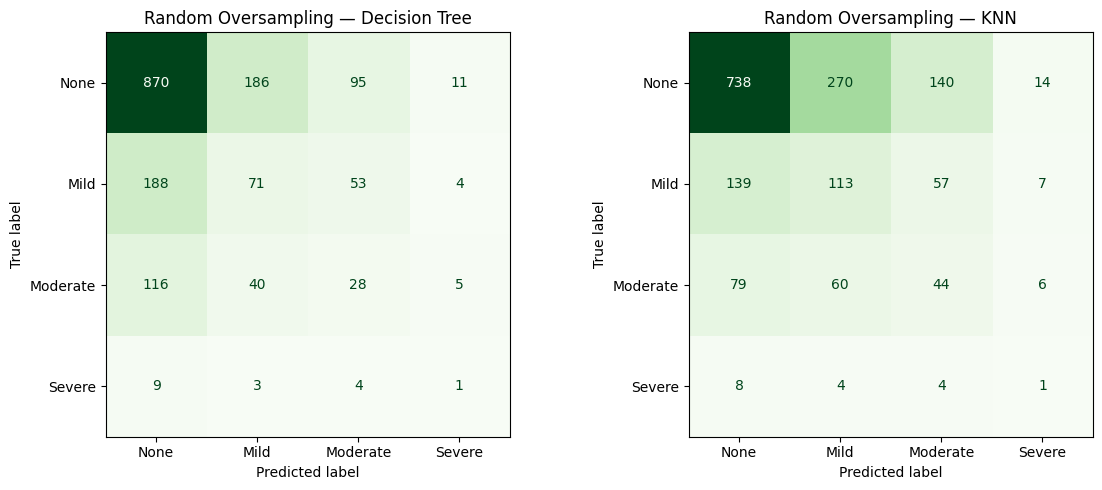

In [ ]:
plot_confusion_pair(y_test, pred_dt_ros, pred_knn_ros, 'Random Oversampling', 'Greens')

---
## Section 5 — Random Undersampling
Randomly removes majority class samples from the **training set only** until all classes match the minority count.  
Reduces training data significantly — risk of losing useful majority class information.  
GridSearchCV re-run on the undersampled training data.  


In [ ]:
# ── Apply Random Undersampling ───────────────────────────────────
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train_scaled, y_train)

print("Random Undersampling — Training Set")
print(f"Before: {len(y_train)} rows")
print(f"After:  {len(y_train_rus)} rows")
print("\nClass distribution after undersampling:")
unique, counts = np.unique(y_train_rus, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  sii={int(cls)}: {cnt}")

Random Undersampling — Training Set
Before: 6733 rows
After:  276 rows

Class distribution after undersampling:
  sii=0: 69
  sii=1: 69
  sii=2: 69
  sii=3: 69


In [ ]:
print("=" * 55)
print("RANDOM UNDERSAMPLING")
print(f"Training set size: {len(y_train_rus)} rows (balanced)")
print("=" * 55)

(m_dt_rus, m_knn_rus,
 pred_dt_rus, pred_knn_rus,
 params_dt_rus, params_knn_rus,
 prob_dt_rus, prob_knn_rus) = tune_and_evaluate(
    X_train_rus, y_train_rus,
    X_test_scaled, y_test,
    label='Random Undersampling'
)

print("\n--- TEST SET RESULTS ---")
print_metrics(m_dt_rus,  'Decision Tree')
print_metrics(m_knn_rus, 'KNN')

all_results.append(('Random Undersampling', 'Decision Tree', m_dt_rus))
all_results.append(('Random Undersampling', 'KNN',           m_knn_rus))
all_preds['RUS DT']  = pred_dt_rus
all_preds['RUS KNN'] = pred_knn_rus

RANDOM UNDERSAMPLING
Training set size: 276 rows (balanced)

Tuning Decision Tree on Random Undersampling data...
  Best params: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 2}
  Best CV F1:  0.3164

Tuning KNN on Random Undersampling data...
  Best params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
  Best CV F1:  0.3404

--- TEST SET RESULTS ---
  Decision Tree
    Accuracy: 0.3325
    Precision: 0.5906
    Recall: 0.3325
    F1-score: 0.4064
    ROC-AUC: 0.5826
  KNN
    Accuracy: 0.3622
    Precision: 0.6096
    Recall: 0.3622
    F1-score: 0.4428
    ROC-AUC: 0.6009


In [ ]:
print("Decision Tree — Classification Report:")
print(classification_report(y_test, pred_dt_rus, target_names=CLASS_NAMES, zero_division=0))
print("KNN — Classification Report:")
print(classification_report(y_test, pred_knn_rus, target_names=CLASS_NAMES, zero_division=0))

Decision Tree — Classification Report:
              precision    recall  f1-score   support

        None       0.77      0.36      0.49      1162
        Mild       0.23      0.28      0.25       316
    Moderate       0.14      0.24      0.18       189
      Severe       0.02      0.47      0.04        17

    accuracy                           0.33      1684
   macro avg       0.29      0.34      0.24      1684
weighted avg       0.59      0.33      0.41      1684

KNN — Classification Report:
              precision    recall  f1-score   support

        None       0.80      0.42      0.55      1162
        Mild       0.22      0.21      0.21       316
    Moderate       0.15      0.23      0.18       189
      Severe       0.02      0.53      0.04        17

    accuracy                           0.36      1684
   macro avg       0.30      0.35      0.25      1684
weighted avg       0.61      0.36      0.44      1684



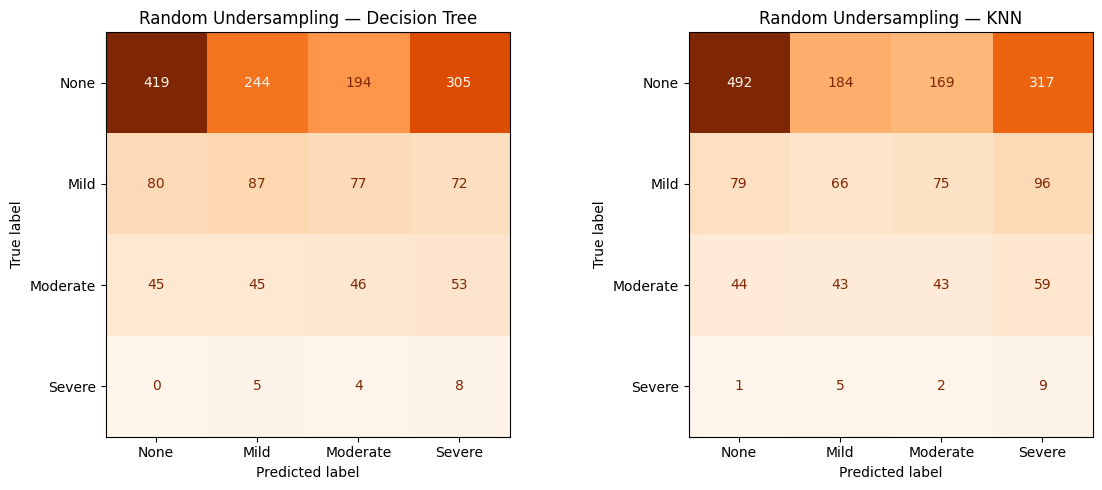

In [ ]:
plot_confusion_pair(y_test, pred_dt_rus, pred_knn_rus, 'Random Undersampling', 'Oranges')

TOMEK LINK

In [ ]:
# Apply Tomek Links

from imblearn.under_sampling import TomekLinks

tl = TomekLinks()
X_train_tl, y_train_tl = tl.fit_resample(X_train_scaled, y_train)

print("Tomek Links — Training Set")
print(f"Before: {len(y_train)} rows")
print(f"After:  {len(y_train_tl)} rows")
print(f"Removed: {len(y_train) - len(y_train_tl)} samples")
print("\nClass distribution after Tomek Links:")
unique, counts = np.unique(y_train_tl, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  sii={int(cls)}: {cnt}")

Tomek Links — Training Set
Before: 6733 rows
After:  6034 rows
Removed: 699 samples

Class distribution after Tomek Links:
  sii=0: 4332
  sii=1: 1016
  sii=2: 617
  sii=3: 69


DECISION TREE AND KNN

In [ ]:
print("TOMEK LINKS")
print(f"Training set size: {len(y_train_tl)} rows")


(m_dt_tl, m_knn_tl,
 pred_dt_tl, pred_knn_tl,
 params_dt_tl, params_knn_tl,
 prob_dt_tl, prob_knn_tl) = tune_and_evaluate(
    X_train_tl, y_train_tl,
    X_test_scaled, y_test,
    label='Tomek Links'
)

print("\n TEST SET RESULTS ")
print_metrics(m_dt_tl,  'Decision Tree')
print_metrics(m_knn_tl, 'KNN')

all_results.append(('Tomek Links', 'Decision Tree', m_dt_tl))
all_results.append(('Tomek Links', 'KNN',           m_knn_tl))
all_preds['Tomek DT']  = pred_dt_tl
all_preds['Tomek KNN'] = pred_knn_tl

TOMEK LINKS
Training set size: 6034 rows

Tuning Decision Tree on Tomek Links data...
  Best params: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 10}
  Best CV F1:  0.6371

Tuning KNN on Tomek Links data...
  Best params: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
  Best CV F1:  0.6523

 TEST SET RESULTS 
  Decision Tree
    Accuracy: 0.639
    Precision: 0.5768
    Recall: 0.639
    F1-score: 0.6016
    ROC-AUC: 0.6297
  KNN
    Accuracy: 0.6781
    Precision: 0.5945
    Recall: 0.6781
    F1-score: 0.6105
    ROC-AUC: 0.6117


In [ ]:
print("Decision Tree — Classification Report:")
print(classification_report(y_test, pred_dt_tl, target_names=CLASS_NAMES, zero_division=0))
print("KNN — Classification Report:")
print(classification_report(y_test, pred_knn_tl, target_names=CLASS_NAMES, zero_division=0))

Decision Tree — Classification Report:
              precision    recall  f1-score   support

        None       0.74      0.86      0.80      1162
        Mild       0.22      0.13      0.17       316
    Moderate       0.24      0.16      0.19       189
      Severe       0.00      0.00      0.00        17

    accuracy                           0.64      1684
   macro avg       0.30      0.29      0.29      1684
weighted avg       0.58      0.64      0.60      1684

KNN — Classification Report:
              precision    recall  f1-score   support

        None       0.72      0.94      0.81      1162
        Mild       0.29      0.10      0.15       316
    Moderate       0.35      0.12      0.18       189
      Severe       0.25      0.06      0.10        17

    accuracy                           0.68      1684
   macro avg       0.40      0.30      0.31      1684
weighted avg       0.59      0.68      0.61      1684



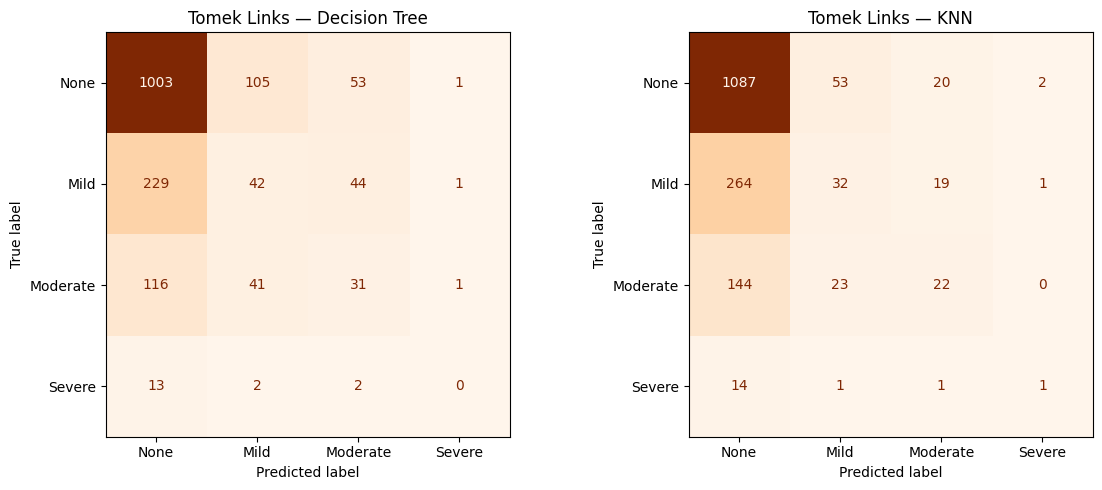

In [ ]:
plot_confusion_pair(y_test, pred_dt_tl, pred_knn_tl, 'Tomek Links', 'Oranges')

SMOTENC

In [ ]:
# Apply SMOTENC

from imblearn.over_sampling import SMOTENC

categorical_cols = [
    'Basic_Demos-Sex', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_Frame_num',
    'SDS_measured', 'BIA_measured', 'Metabolic_Alarms_Count',
    'ScreenTime_Category', 'PreInt_EduHx-computerinternet_hoursday'
]
# Get indices from original X (before scaling)
feature_cols = [c for c in df.columns if c != 'sii']
X_orig = df[feature_cols]
cat_features = [X_orig.columns.get_loc(c) for c in categorical_cols]

smote_nc = SMOTENC(categorical_features=cat_features, random_state=42)
X_train_smote, y_train_smote = smote_nc.fit_resample(X_train_scaled, y_train)

print("SMOTENC — Training Set")
print(f"Before: {len(y_train)} rows")
print(f"After:  {len(y_train_smote)} rows")
print("\nClass distribution after SMOTENC:")
unique, counts = np.unique(y_train_smote, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  sii={int(cls)}: {cnt}")

SMOTENC — Training Set
Before: 6733 rows
After:  18576 rows

Class distribution after SMOTENC:
  sii=0: 4644
  sii=1: 4644
  sii=2: 4644
  sii=3: 4644


DT and KNN

In [ ]:
print("SMOTENC")
print(f"Training set size: {len(y_train_smote)} rows (balanced)")


(m_dt_smote, m_knn_smote,
 pred_dt_smote, pred_knn_smote,
 params_dt_smote, params_knn_smote,
 prob_dt_smote, prob_knn_smote) = tune_and_evaluate(
    X_train_smote, y_train_smote,
    X_test_scaled, y_test,
    label='SMOTENC'
)

print("\n TEST SET RESULTS ")
print_metrics(m_dt_smote,  'Decision Tree')
print_metrics(m_knn_smote, 'KNN')

all_results.append(('SMOTENC', 'Decision Tree', m_dt_smote))
all_results.append(('SMOTENC', 'KNN',           m_knn_smote))
all_preds['SMOTENC DT']  = pred_dt_smote
all_preds['SMOTENC KNN'] = pred_knn_smote

SMOTENC
Training set size: 18576 rows (balanced)

Tuning Decision Tree on SMOTENC data...
  Best params: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2}
  Best CV F1:  0.7438

Tuning KNN on SMOTENC data...
  Best params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
  Best CV F1:  0.8622

 TEST SET RESULTS 
  Decision Tree
    Accuracy: 0.5143
    Precision: 0.5758
    Recall: 0.5143
    F1-score: 0.54
    ROC-AUC: 0.5633
  KNN
    Accuracy: 0.4852
    Precision: 0.581
    Recall: 0.4852
    F1-score: 0.5226
    ROC-AUC: 0.5899


In [ ]:
print("Decision Tree — Classification Report:")
print(classification_report(y_test, pred_dt_smote, target_names=CLASS_NAMES, zero_division=0))
print("KNN — Classification Report:")
print(classification_report(y_test, pred_knn_smote, target_names=CLASS_NAMES, zero_division=0))

Decision Tree — Classification Report:
              precision    recall  f1-score   support

        None       0.75      0.63      0.68      1162
        Mild       0.20      0.26      0.23       316
    Moderate       0.21      0.29      0.24       189
      Severe       0.03      0.06      0.04        17

    accuracy                           0.51      1684
   macro avg       0.30      0.31      0.30      1684
weighted avg       0.58      0.51      0.54      1684

KNN — Classification Report:
              precision    recall  f1-score   support

        None       0.76      0.58      0.66      1162
        Mild       0.20      0.28      0.23       316
    Moderate       0.17      0.26      0.20       189
      Severe       0.02      0.06      0.03        17

    accuracy                           0.49      1684
   macro avg       0.29      0.30      0.28      1684
weighted avg       0.58      0.49      0.52      1684



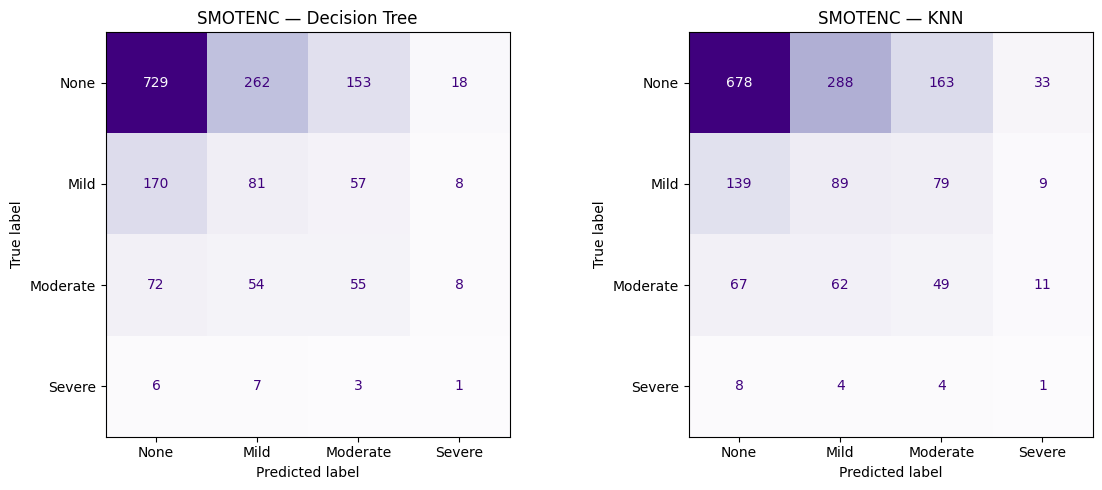

In [ ]:
plot_confusion_pair(y_test, pred_dt_smote, pred_knn_smote, 'SMOTENC', 'Purples')

TL + SMOTENC

In [ ]:
# Apply SMOTENC → Tomek Linksì
X_train_hybrid, y_train_hybrid = TomekLinks().fit_resample(X_train_smote, y_train_smote)

print("Hybrid (SMOTENC + Tomek Links) — Training Set")
print(f"After SMOTENC: {len(y_train_smote)} rows")
print(f"After Tomek:   {len(y_train_hybrid)} rows")
print(f"Cleaned:       {len(y_train_smote) - len(y_train_hybrid)} synthetic border samples")
print("\nClass distribution after Hybrid:")
unique, counts = np.unique(y_train_hybrid, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  sii={int(cls)}: {cnt}")

Hybrid (SMOTENC + Tomek Links) — Training Set
After SMOTENC: 18576 rows
After Tomek:   18470 rows
Cleaned:       106 synthetic border samples

Class distribution after Hybrid:
  sii=0: 4644
  sii=1: 4574
  sii=2: 4616
  sii=3: 4636


In [ ]:
print("(SMOTENC + Tomek Links)")
print(f"Training set size: {len(y_train_hybrid)} rows")


(m_dt_hybrid, m_knn_hybrid,
 pred_dt_hybrid, pred_knn_hybrid,
 params_dt_hybrid, params_knn_hybrid,
 prob_dt_hybrid, prob_knn_hybrid) = tune_and_evaluate(
    X_train_hybrid, y_train_hybrid,
    X_test_scaled, y_test,
    label='Hybrid'
)

print("\n TEST SET RESULTS ")
print_metrics(m_dt_hybrid,  'Decision Tree')
print_metrics(m_knn_hybrid, 'KNN')

all_results.append(('Hybrid (SMOTENC+Tomek)', 'Decision Tree', m_dt_hybrid))
all_results.append(('Hybrid (SMOTENC+Tomek)', 'KNN',           m_knn_hybrid))
all_preds['Hybrid DT']  = pred_dt_hybrid
all_preds['Hybrid KNN'] = pred_knn_hybrid

(SMOTENC + Tomek Links)
Training set size: 18470 rows

Tuning Decision Tree on Hybrid data...
  Best params: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2}
  Best CV F1:  0.7425

Tuning KNN on Hybrid data...
  Best params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
  Best CV F1:  0.8664

 TEST SET RESULTS 
  Decision Tree
    Accuracy: 0.5089
    Precision: 0.5718
    Recall: 0.5089
    F1-score: 0.5354
    ROC-AUC: 0.5587
  KNN
    Accuracy: 0.4869
    Precision: 0.5823
    Recall: 0.4869
    F1-score: 0.5243
    ROC-AUC: 0.589


In [ ]:
print("Decision Tree — Classification Report:")
print(classification_report(y_test, pred_dt_hybrid, target_names=CLASS_NAMES, zero_division=0))
print("KNN — Classification Report:")
print(classification_report(y_test, pred_knn_hybrid, target_names=CLASS_NAMES, zero_division=0))

Decision Tree — Classification Report:
              precision    recall  f1-score   support

        None       0.74      0.63      0.68      1162
        Mild       0.20      0.25      0.22       316
    Moderate       0.18      0.26      0.21       189
      Severe       0.03      0.06      0.04        17

    accuracy                           0.51      1684
   macro avg       0.29      0.30      0.29      1684
weighted avg       0.57      0.51      0.54      1684

KNN — Classification Report:
              precision    recall  f1-score   support

        None       0.76      0.59      0.66      1162
        Mild       0.20      0.28      0.23       316
    Moderate       0.17      0.26      0.21       189
      Severe       0.02      0.06      0.03        17

    accuracy                           0.49      1684
   macro avg       0.29      0.30      0.28      1684
weighted avg       0.58      0.49      0.52      1684



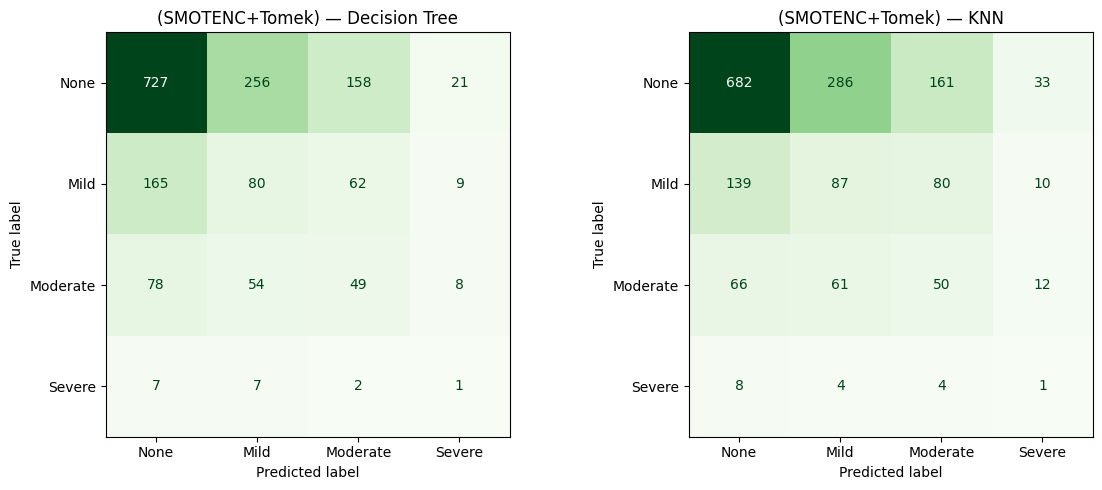

In [ ]:
plot_confusion_pair(y_test, pred_dt_hybrid, pred_knn_hybrid, '(SMOTENC+Tomek)', 'Greens')

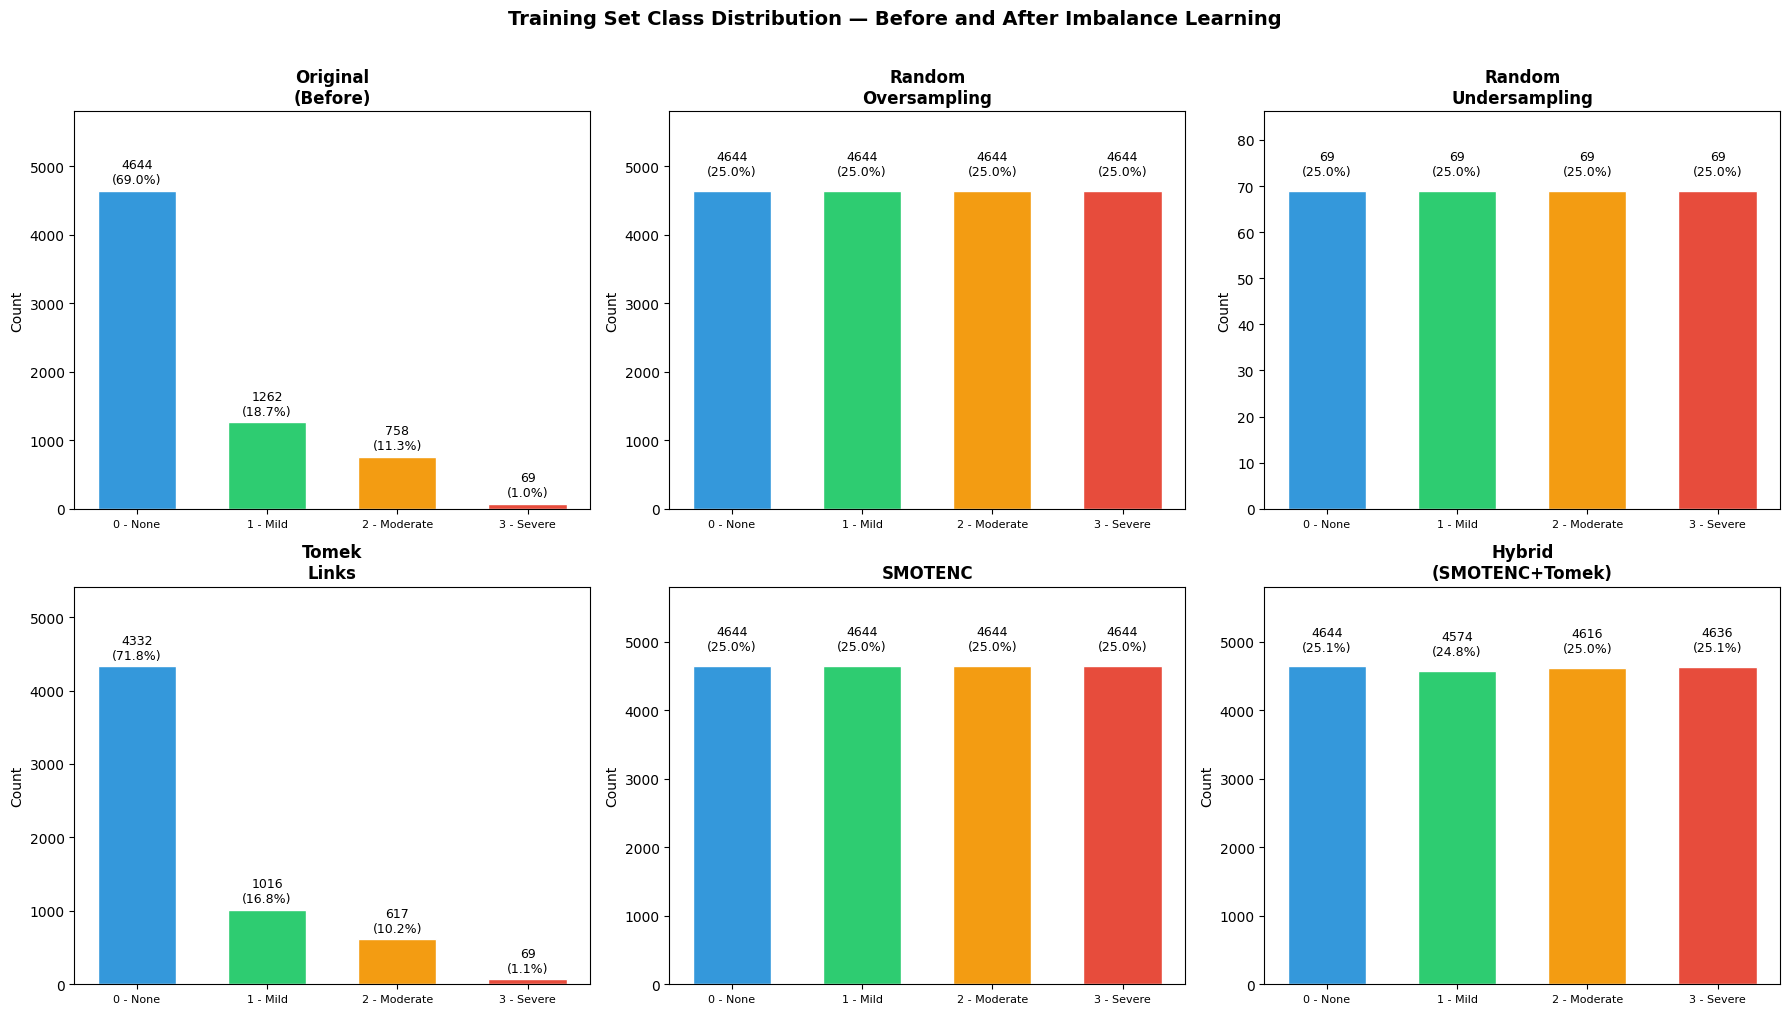

Method                            sii=0    sii=1    sii=2    sii=3    Total
----------------------------------------------------------------------
Original (Before)                  4644     1262      758       69     6733
Random Oversampling                4644     4644     4644     4644    18576
Random Undersampling                 69       69       69       69      276
Tomek Links                        4332     1016      617       69     6034
SMOTENC                            4644     4644     4644     4644    18576
Hybrid (SMOTENC+Tomek)             4644     4574     4616     4636    18470


In [ ]:
# ── Class Distribution: Before vs After All Resampling Techniques ──────────────

from collections import Counter

CLASS_LABELS = ['0 - None', '1 - Mild', '2 - Moderate', '3 - Severe']
COLORS = ['#3498DB', '#2ECC71', '#F39C12', '#E74C3C']

distributions = {
    'Original\n(Before)':         Counter(y_train),
    'Random\nOversampling':       Counter(y_train_ros),
    'Random\nUndersampling':      Counter(y_train_rus),
    'Tomek\nLinks':               Counter(y_train_tl),
    'SMOTENC':                    Counter(y_train_smote),
    'Hybrid\n(SMOTENC+Tomek)':   Counter(y_train_hybrid),
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (title, counter) in zip(axes, distributions.items()):
    counts = [counter.get(cls, 0) for cls in [0, 1, 2, 3]]
    total  = sum(counts)
    bars   = ax.bar(CLASS_LABELS, counts, color=COLORS, edgecolor='white', width=0.6)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.01,
                f'{cnt}\n({cnt/total*100:.1f}%)',
                ha='center', va='bottom', fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_ylim(0, max(counts) * 1.25)
    ax.tick_params(axis='x', labelsize=8)

plt.suptitle('Training Set Class Distribution — Before and After Imbalance Learning',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('class_distribution_all_methods.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print summary table ─────────────────────────────────────────────────────
print(f"{'Method':<30} {'sii=0':>8} {'sii=1':>8} {'sii=2':>8} {'sii=3':>8} {'Total':>8}")
print("-" * 70)
for title, counter in distributions.items():
    title_flat = title.replace('\n', ' ')
    counts = [counter.get(c, 0) for c in [0, 1, 2, 3]]
    print(f"{title_flat:<30} {counts[0]:>8} {counts[1]:>8} {counts[2]:>8} {counts[3]:>8} {sum(counts):>8}")

---
## Section 6 — Results Comparison
All techniques compared on the same held-out test set.  


In [ ]:
# ── Build results table ──────────────────────────────────────────
rows = []
for method, model, m in all_results:
    rows.append({
        'Method':    method,
        'Model':     model,
        'Accuracy':  m['Accuracy'],
        'Precision': m['Precision'],
        'Recall':    m['Recall'],
        'F1-score':  m['F1-score'],
        'ROC-AUC':   m['ROC-AUC'],
    })

results_df = pd.DataFrame(rows)
print("=" * 85)
print(results_df.to_string(index=False))
results_df.to_csv('module2_results.csv', index=False)
print("\nSaved: module2_results.csv")

                Method         Model  Accuracy  Precision  Recall  F1-score  ROC-AUC
              Baseline Decision Tree    0.6811     0.5763  0.6811    0.5987   0.6680
              Baseline           KNN    0.6568     0.5774  0.6568    0.5986   0.6167
   Random Oversampling Decision Tree    0.5760     0.5698  0.5760    0.5728   0.5597
   Random Oversampling           KNN    0.5321     0.5962  0.5321    0.5578   0.5941
  Random Undersampling Decision Tree    0.3325     0.5906  0.3325    0.4064   0.5826
  Random Undersampling           KNN    0.3622     0.6096  0.3622    0.4428   0.6009
           Tomek Links Decision Tree    0.6390     0.5768  0.6390    0.6016   0.6297
           Tomek Links           KNN    0.6781     0.5945  0.6781    0.6105   0.6117
               SMOTENC Decision Tree    0.5143     0.5758  0.5143    0.5400   0.5633
               SMOTENC           KNN    0.4852     0.5810  0.4852    0.5226   0.5899
Hybrid (SMOTENC+Tomek) Decision Tree    0.5089     0.5718  0.5089

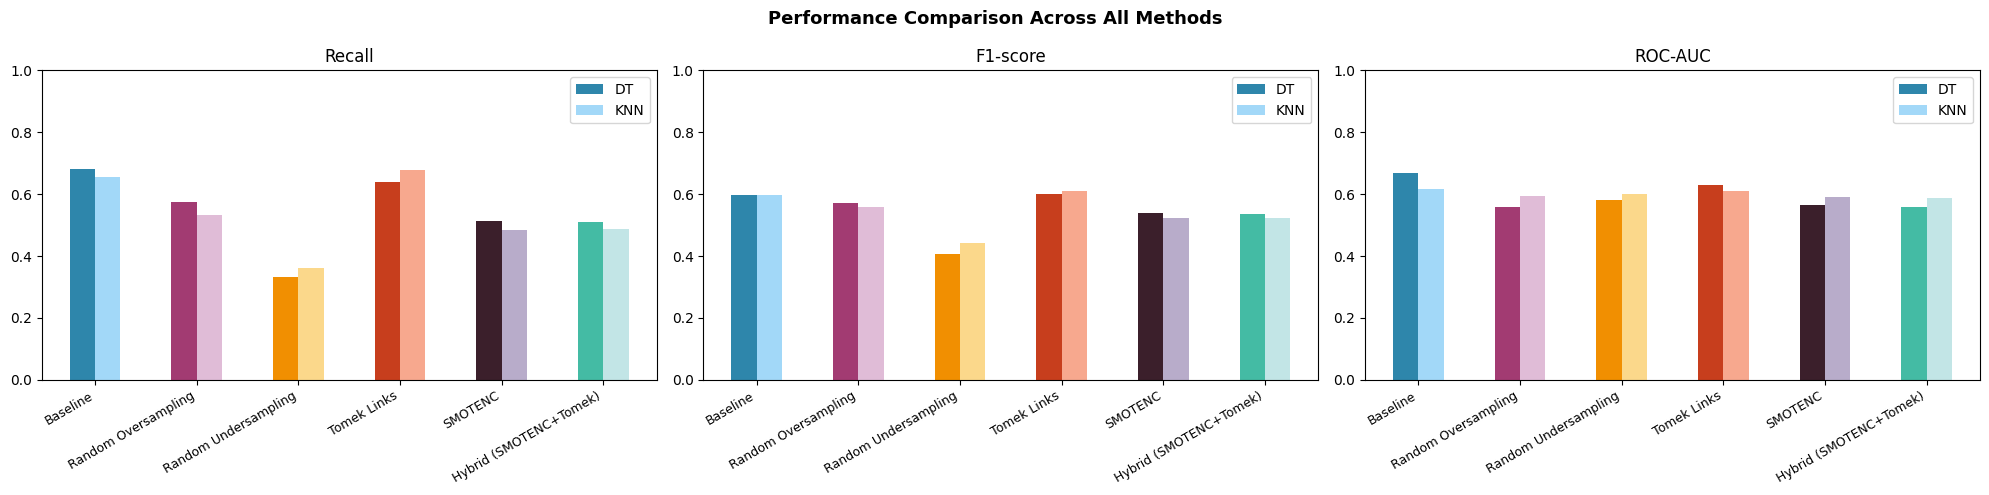

In [ ]:
metrics_to_plot = ['Recall', 'F1-score', 'ROC-AUC']
methods_order = ['Baseline', 'Random Oversampling', 'Random Undersampling',
                 'Tomek Links', 'SMOTENC', 'Hybrid (SMOTENC+Tomek)']
x = np.arange(len(methods_order))
width = 0.25

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
palette_dt  = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B', '#44BBA4']
palette_knn = ['#7BC8F6', '#D4A0C7', '#FAC85A', '#F4845F', '#9B89B4', '#A8DADC']

for ax, metric, c_dt, c_knn in zip(axes, metrics_to_plot, palette_dt, palette_knn):
    dt_vals  = [results_df[(results_df['Method']==m) & (results_df['Model']=='Decision Tree')][metric].values[0]
                for m in methods_order]
    knn_vals = [results_df[(results_df['Method']==m) & (results_df['Model']=='KNN')][metric].values[0]
                for m in methods_order]

    ax.bar(x - width/2, dt_vals,  width, label='DT',  color=palette_dt)
    ax.bar(x + width/2, knn_vals, width, label='KNN', color=palette_knn, alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(methods_order, rotation=30, ha='right', fontsize=9)
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.legend()

plt.suptitle('Performance Comparison Across All Methods', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

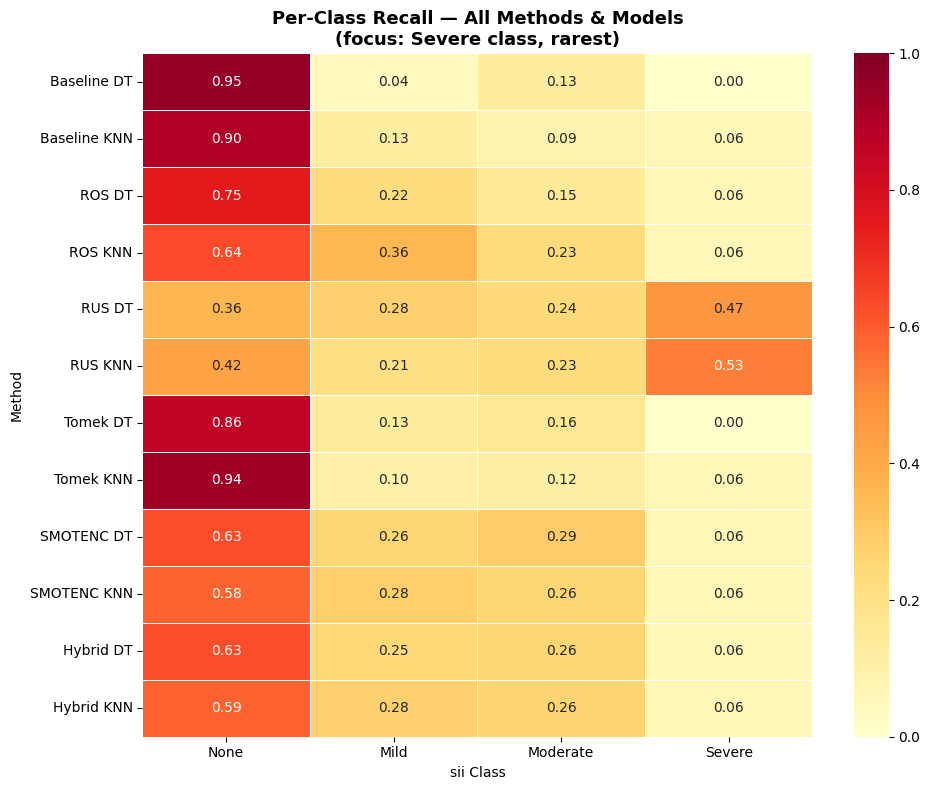

In [ ]:
from sklearn.metrics import recall_score as rec_score

configs = [
    ('Baseline DT',    pred_dt_base),
    ('Baseline KNN',   pred_knn_base),
    ('ROS DT',         pred_dt_ros),
    ('ROS KNN',        pred_knn_ros),
    ('RUS DT',         pred_dt_rus),
    ('RUS KNN',        pred_knn_rus),
    ('Tomek DT',       pred_dt_tl),
    ('Tomek KNN',      pred_knn_tl),
    ('SMOTENC DT',     pred_dt_smote),
    ('SMOTENC KNN',    pred_knn_smote),
    ('Hybrid DT',      pred_dt_hybrid),
    ('Hybrid KNN',     pred_knn_hybrid),
]

per_class = {}
for lbl, y_pred in configs:
    per_class[lbl] = rec_score(y_test, y_pred, labels=CLASSES, average=None, zero_division=0)

heatmap_df = pd.DataFrame(per_class, index=CLASS_NAMES).T

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_df, annot=True, fmt='.2f', cmap='YlOrRd',
            vmin=0, vmax=1, linewidths=0.5)
plt.title('Per-Class Recall — All Methods & Models\n(focus: Severe class, rarest)',
          fontsize=13, fontweight='bold')
plt.xlabel('sii Class')
plt.ylabel('Method')
plt.tight_layout()
plt.show()

In [ ]:
# ── Summary printout ─────────────────────────────────────────────
print("=" * 60)
print("SUMMARY")
print("=" * 60)

best_f1  = results_df.loc[results_df['F1-score'].idxmax()]
best_rec = results_df.loc[results_df['Recall'].idxmax()]

print(f"\nBest F1-score:  {best_f1['Method']} — {best_f1['Model']} ({best_f1['F1-score']})")
print(f"Best Recall:    {best_rec['Method']} — {best_rec['Model']} ({best_rec['Recall']})")

print("\nsii=3 (Severe) Recall per configuration:")
for lbl, y_pred in configs:
    r = rec_score(y_test, y_pred, labels=CLASSES, average=None, zero_division=0)
    print(f"  {lbl:<18}: {r[3]:.4f}")

print("\nHyperparameters selected per technique:")
print(f"  Baseline  — DT:  {params_dt_base}")
print(f"  Baseline  — KNN: {params_knn_base}")
print(f"  ROS       — DT:  {params_dt_ros}")
print(f"  ROS       — KNN: {params_knn_ros}")
print(f"  RUS       — DT:  {params_dt_rus}")
print(f"  RUS       — KNN: {params_knn_rus}")

SUMMARY

Best F1-score:  Tomek Links — KNN (0.6105)
Best Recall:    Baseline — Decision Tree (0.6811)

sii=3 (Severe) Recall per configuration:
  Baseline DT       : 0.0000
  Baseline KNN      : 0.0588
  ROS DT            : 0.0588
  ROS KNN           : 0.0588
  RUS DT            : 0.4706
  RUS KNN           : 0.5294
  Tomek DT          : 0.0000
  Tomek KNN         : 0.0588
  SMOTENC DT        : 0.0588
  SMOTENC KNN       : 0.0588
  Hybrid DT         : 0.0588
  Hybrid KNN        : 0.0588

Hyperparameters selected per technique:
  Baseline  — DT:  {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2}
  Baseline  — KNN: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
  ROS       — DT:  {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2}
  ROS       — KNN: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
  RUS       — DT:  {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 2}
  RUS       — KNN: {'metric': 'manhattan', 'n_nei

In [ ]:
import inspect
print(inspect.getsource(tune_and_evaluate))
print(inspect.getsource(print_metrics))
print(inspect.getsource(plot_confusion_pair))

def tune_and_evaluate(X_tr, y_tr, X_te, y_te, label):
    """
    1. GridSearchCV Decision Tree on (X_tr, y_tr)
    2. GridSearchCV KNN on (X_tr, y_tr)
    3. Evaluate both on (X_te, y_te)
    Returns: (dt_metrics, knn_metrics, dt_preds, knn_preds, dt_best_params, knn_best_params)
    """
    print(f"\nTuning Decision Tree on {label} data...")
    dt_gs = GridSearchCV(DecisionTreeClassifier(random_state=42), DT_GRID,
                         cv=CV, scoring='f1_weighted', n_jobs=-1)
    dt_gs.fit(X_tr, y_tr)
    best_dt = dt_gs.best_estimator_
    print(f"  Best params: {dt_gs.best_params_}")
    print(f"  Best CV F1:  {dt_gs.best_score_:.4f}")

    print(f"\nTuning KNN on {label} data...")
    knn_gs = GridSearchCV(KNeighborsClassifier(), KNN_GRID,
                          cv=CV, scoring='f1_weighted', n_jobs=-1)
    knn_gs.fit(X_tr, y_tr)
    best_knn = knn_gs.best_estimator_
    print(f"  Best params: {knn_gs.best_params_}")
    print(f"  Best CV F1:  {knn_gs.best_score_:.4f}")

   